In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


i mistakenly thought we didn't have the dataset for this project so i imported one, they are very similar with the only change being destination not being included and i don't think it would affect survival rate.

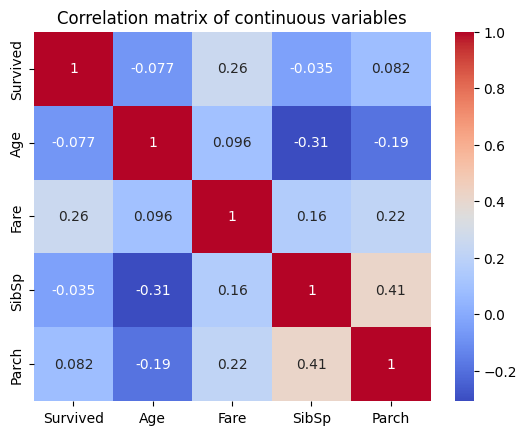

In [53]:
continuous_features = ['Survived', 'Age', 'Fare', 'SibSp', 'Parch']

corr = df[continuous_features].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation matrix of continuous variables")
plt.show()


there is a strong positive correlation between SibSp (siblings/spouses) and Parch (parents/children), as family members typically traveled together, and a notable negative correlation between Pclass and Age, reflecting that wealthier first-class passengers tended to be older. However, when looking strictly at the numerical values in this matrix, Fare stands out as the best variable for predicting survival. Its positive correlation indicates that higher-spending passengers had a significantly better chance of reaching a lifeboat, likely due to the superior location of high-cost cabins.

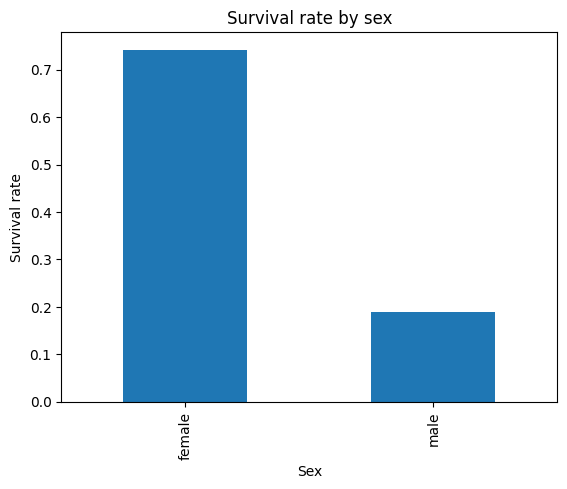

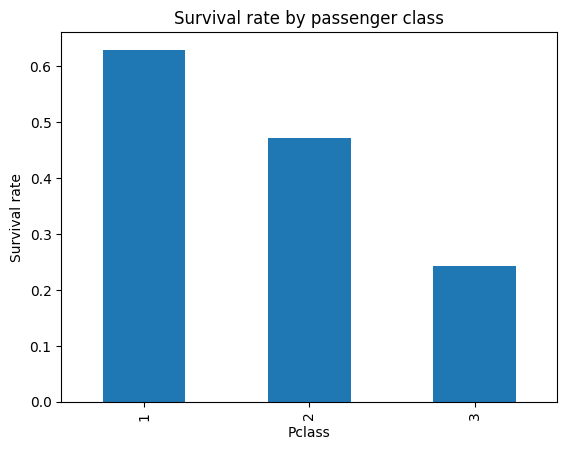

In [54]:
plt.figure()
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.ylabel("Survival rate")
plt.title("Survival rate by sex")
plt.show()

plt.figure()
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.ylabel("Survival rate")
plt.title("Survival rate by passenger class")
plt.show()


Females have a much higher survival rate than males (Women and children first policy when it comes to life boats). Survival probability also strongly depends on passenger class, with first-class passengers being the most likely to survive.

In [55]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [56]:
df = df.drop(columns=['Cabin'])
df['Age_missing'] = df['Age'].isnull().astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


Age and Embarked contain missing values. Cabin has too many missing entries and is removed. Age is filled using the median, and Age_Missing is added to avoid messing with the balance of the model by filling 20% of the dataset with median age, and Embarked is filled with the most frequent value.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

features = ['Pclass', 'Sex', 'Fare', 'SibSp', 'Parch', 'Embarked', 'Age_missing','Age']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [62]:
from sklearn.model_selection import GridSearchCV

param_grid = [
  {'n_estimators': np.arange(30,300,30)},
  { 'max_depth':np.arange(3,30,3)} 
]

rf = RandomForestClassifier(n_jobs=-1)

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1,)

grid_search.fit(X, y)

print(f"Best score (accuracy): {grid_search.best_score_*100:.6f}")

best_rf_model = grid_search.best_estimator_

Best score (accuracy): 82.717344


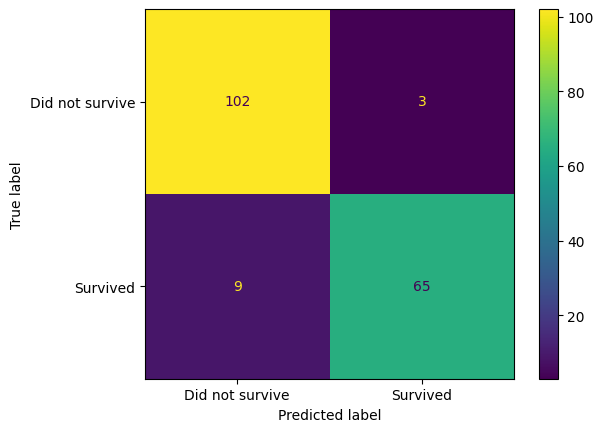

In [63]:
y_pred=best_rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Did not survive", "Survived"])
disp.plot()
plt.show()


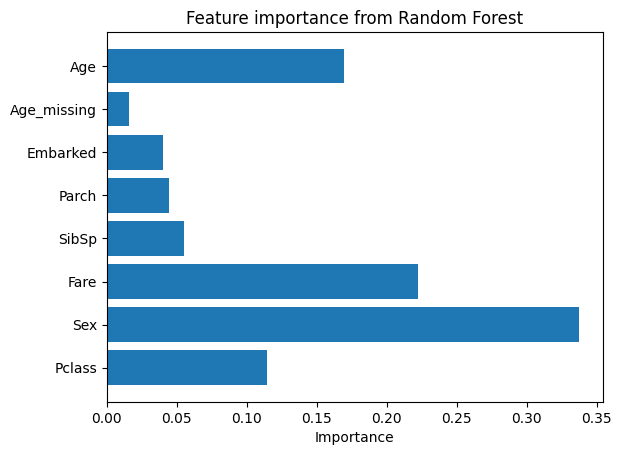

Exception ignored in: <function ResourceTracker.__del__ at 0x7f34ef33a3e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f1feb65a3e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/usr/lib64/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fc3fd3de3e0>
Traceback (most recent call last):
  File "/usr/lib64/python3.13/multip

In [ ]:
importances = best_rf_model.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature importance from Random Forest")
plt.show()


Sex and Fare class are the most important predictors, followed by Age and Passenger class. These results are consistent with historical knowledge of the Titanic disaster.

## Conclusion:
This study shows that exploratory data analysis, proper handling of missing data, and ensemble learning methods can produce an effective predictive model. Random Forest offers both strong performance and interpretability for survival prediction.